In [ ]:
import pandas as pd
from stock_prediction.constants import *
from stock_prediction.utils.common import *
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


In [4]:
import os
# os.chdir("../")

In [20]:

config = read_yaml(CONFIG_FILE_PATH)
df = pd.read_csv(config.data_ingestion.raw_data_file)
df.head()

2026-08-10 19:37:04,636 | INFO | common| YAML file: config\config.yaml loaded successfully.


,Date,Close,High,Low,Open,Volume
0,2000-01-03,0.837724,0.841934,0.761015,0.784870,535796800
1,2000-01-04,0.767096,0.827901,0.757273,0.810128,512377600
2,2000-01-05,0.778321,0.827434,0.770837,0.776450,778321600
3,2000-01-06,0.710966,0.800772,0.710966,0.794225,767972800
4,2000-01-07,0.744644,0.755870,0.714709,0.722192,460734400


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6685 entries, 0 to 6684
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6685 non-null   object 
 1   Close   6685 non-null   float64
 2   High    6685 non-null   float64
 3   Low     6685 non-null   float64
 4   Open    6685 non-null   float64
 5   Volume  6685 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 313.5+ KB


In [22]:
df["Date"] = pd.to_datetime(df["Date"], )
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6685 entries, 0 to 6684
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6685 non-null   datetime64[ns]
 1   Close   6685 non-null   float64       
 2   High    6685 non-null   float64       
 3   Low     6685 non-null   float64       
 4   Open    6685 non-null   float64       
 5   Volume  6685 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 313.5 KB


In [27]:
df = df.set_index("Date",)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,0.837724,0.841934,0.761015,0.784870,535796800
2000-01-04,0.767096,0.827901,0.757273,0.810128,512377600
2000-01-05,0.778321,0.827434,0.770837,0.776450,778321600
2000-01-06,0.710966,0.800772,0.710966,0.794225,767972800
2000-01-07,0.744644,0.755870,0.714709,0.722192,460734400


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6685 entries, 2000-01-03 to 2026-08-03
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6685 non-null   float64
 1   High    6685 non-null   float64
 2   Low     6685 non-null   float64
 3   Open    6685 non-null   float64
 4   Volume  6685 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 313.4 KB


In [34]:
df = df[["Close"]]
df.head()

,Close
Date,
2000-01-03,0.837724
2000-01-04,0.767096
2000-01-05,0.778321
2000-01-06,0.710966
2000-01-07,0.744644


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6685 entries, 2000-01-03 to 2026-08-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6685 non-null   float64
dtypes: float64(1)
memory usage: 104.5 KB


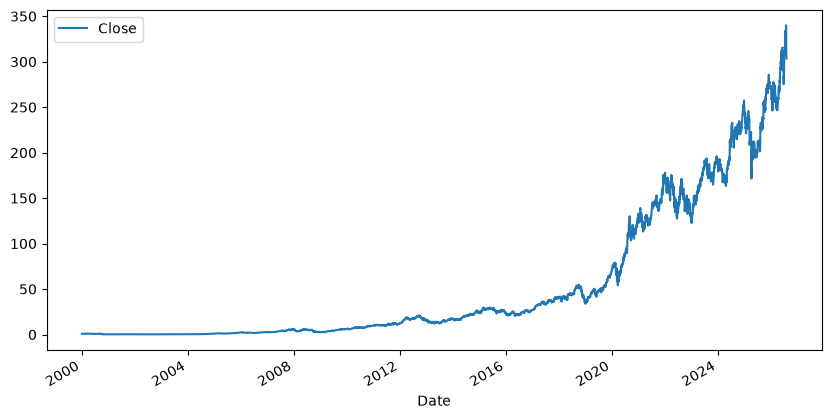

In [36]:
df.plot(figsize=(10, 5));

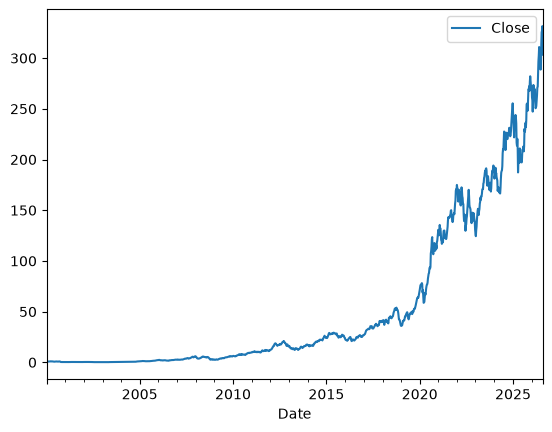

In [43]:
df.resample(rule="W").mean().plot();

## Simple Moving Average

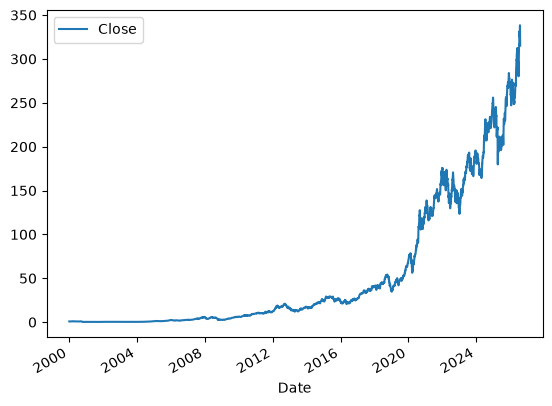

In [56]:
# df.plot()
df.rolling(3).mean().plot();

In [58]:
import matplotlib.pyplot as plt

In [ ]:
df.Close.rolling(window=5).mean().plot()


Object `plot` not found.


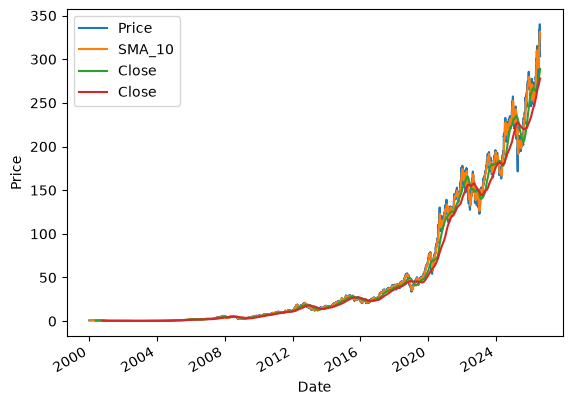

In [75]:
df.Close.plot(label="Price")
df.Close.rolling(window=10).mean().plot(label="SMA_10")
df.Close.rolling(window=100).mean().plot()
df.Close.rolling(window=200).mean().plot();

# plt.plot(df.index, df["Close"], label="Close")
# plt.plot(df.index, df["SMA_20"], label="SMA_20")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
plt.plot(df.index, df.Close, label="Close")

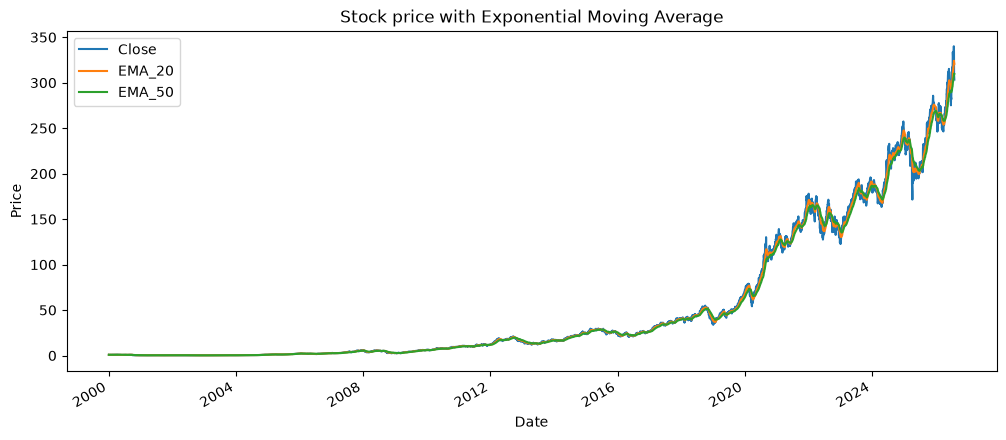

In [86]:
plt.figure(figsize=(12, 5))
df.Close.plot(label="Close")
df.Close.ewm(span=20, adjust=False).mean().plot(label="EMA_20")
df.Close.ewm(span=50, adjust=False).mean().plot(label="EMA_50")
plt.title("Stock price with Exponential Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

<Axes: xlabel='Date'>

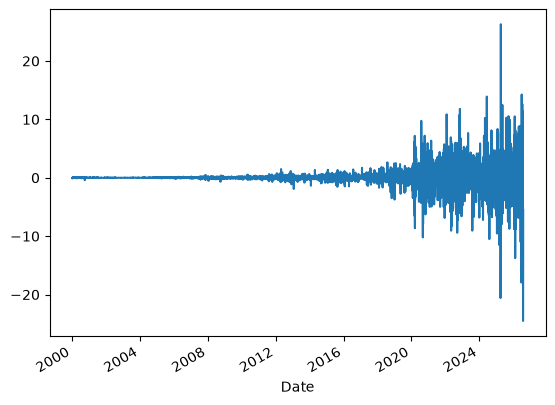

In [95]:
df.Close.diff(periods=1).plot()

<Axes: xlabel='Date'>

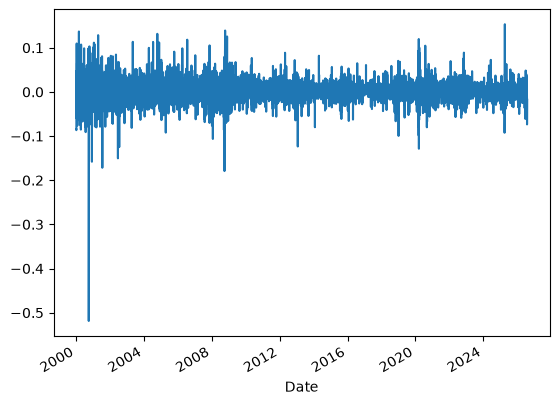

In [97]:
df.Close.pct_change().plot()

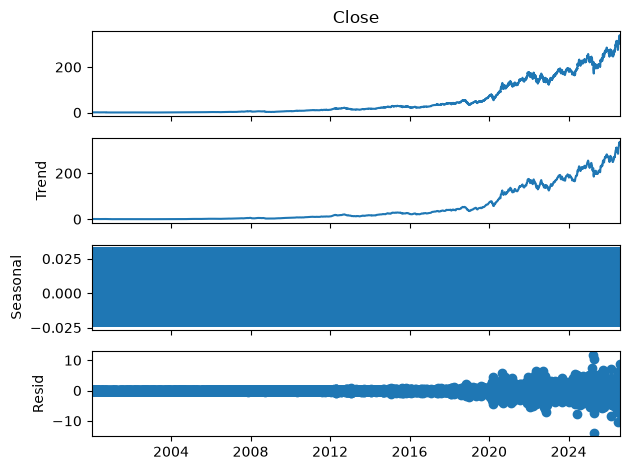

In [152]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(
    df.Close, model="additive", period=5
)
decomposition.plot();

In [151]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residue = decomposition.resid

In [118]:
def adfuller_test(series):
    result = adfuller(
        series.dropna()
    )
    print(f"ADF statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    return result

In [119]:
adfuller_test(df.Close)

ADF statistic: 2.9681624455206093
p-value: 1.0


(np.float64(2.9681624455206093),
 1.0,
 32,
 6652,
 {'1%': np.float64(-3.431333437349177),
  '5%': np.float64(-2.861974596723569),
  '10%': np.float64(-2.567001332272852)},
 np.float64(25332.135443131676))

In [122]:
adfuller_test(df.Close.diff())

ADF statistic: -15.61665036584245
p-value: 1.7526417780972735e-28


(np.float64(-15.61665036584245),
 np.float64(1.7526417780972735e-28),
 31,
 6652,
 {'1%': np.float64(-3.431333437349177),
  '5%': np.float64(-2.861974596723569),
  '10%': np.float64(-2.567001332272852)},
 np.float64(25336.17522714648))

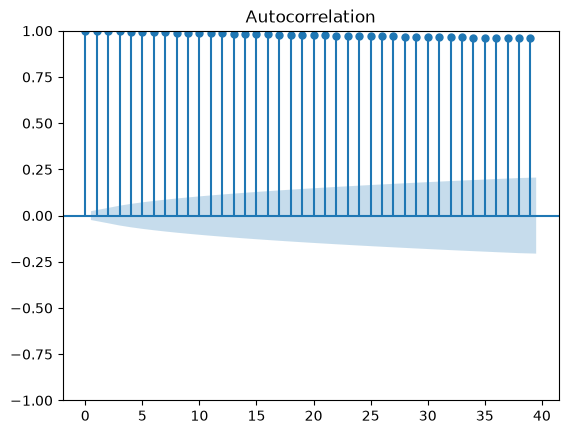

In [124]:
plot_acf(df.Close);

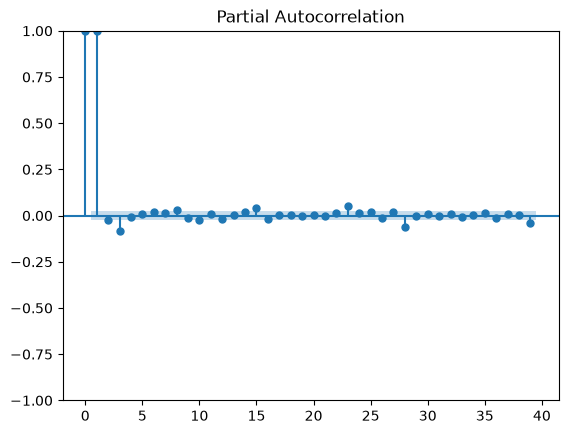

In [126]:
plot_pacf(df.Close);

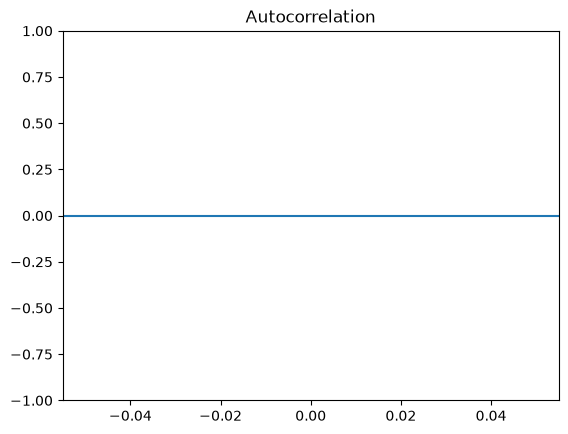

In [227]:
plot_acf(df.Close.diff(2));

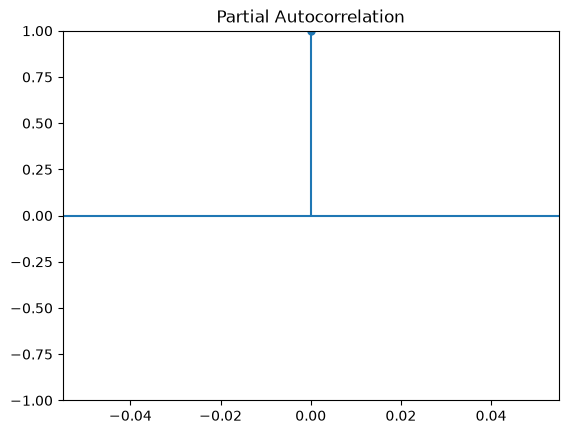

In [230]:
plot_pacf(df.Close.diff(2));

In [120]:
# !pip install statsmodels

In [97]:
df.Close.corr(df.Close.shift(1))

np.float64(0.999773340559251)

In [90]:
df.Close.diff(2)

Date
2000-01-03          NaN
2000-01-04          NaN
2000-01-05    -0.059404
2000-01-06    -0.056130
2000-01-07    -0.033677
                ...    
2026-07-28     7.059998
2026-07-29     1.279999
2026-07-30    -6.649994
2026-07-31   -29.279999
2026-08-03   -30.009979
Name: Close, Length: 6685, dtype: float64

In [136]:
data = df.Close

train_size = int(len(data) * 0.7)
train_size

4679

In [140]:
train  = data.iloc[:train_size]
test= data.iloc[train_size:]
test

Date
2018-08-08     48.831352
2018-08-09     49.215401
2018-08-10     49.068806
2018-08-13     49.385647
2018-08-14     49.593708
                 ...    
2026-07-28    340.079987
2026-07-29    338.190002
2026-07-30    333.429993
2026-07-31    308.910004
2026-08-03    303.420013
Name: Close, Length: 2006, dtype: float64

In [143]:
from statsmodels.tsa.arima.model import ARIMA

In [142]:
assert(len(train) + len(test) == len(data))

In [162]:
# !pip install pmdarima

In [165]:
from pmdarima.arima.utils import ndiffs
import pmdarima as pm

In [164]:
ndiffs(df.Close, test="adf")

1

In [166]:
model = pm.auto_arima(train, seasonal=True)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 4679
Model:               SARIMAX(5, 2, 0)   Log Likelihood                -205.847
Date:                Mon, 10 Aug 2026   AIC                            423.694
Time:                        22:13:36   BIC                            462.396
Sample:                             0   HQIC                           437.304
                               - 4679                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7878      0.007   -109.758      0.000      -0.802      -0.774
ar.L2         -0.6579      0.009    -72.429      0.000      -0.676      -0.640
ar.L3         -0.5098      0.010    -49.040      0.000      -0.530      -0.489
ar.L4         -0.3054      0.009    -33.311      0.000      -0.323      -0.287
ar.L5         -0.1619      0.007    -21.852      0.000      -0.176      -0.147
sigma2         0.0639      0.000    134.534      0.000       0.063       0.065
===================================================================================
Ljung-Box (L1) (Q):                   3.53   Jarque-Bera (JB):             43364.62
Prob(Q):                              0.06   Prob(JB):                         0.00
Heteroskedasticity (H):             216.34   Skew:                             0.64
Prob(H) (two-sided):                  0.00   Kurtosis:                        17.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [189]:
arima_model = ARIMA(
    train, order=(5,2, 0)
)
arima_model = model.fit()


c:\Users\Ibk\Desktop\data project\Stock-Price-Prediction-MLOps\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Ibk\Desktop\data project\Stock-Price-Prediction-MLOps\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Ibk\Desktop\data project\Stock-Price-Prediction-MLOps\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [200]:
forecast = arima_model.forecast(len(test))
forecast

array([ 49.43153867,  50.19924596,  50.6729541 , ..., 845.7168533 ,
       846.1142636 , 846.51167391], shape=(2006,))

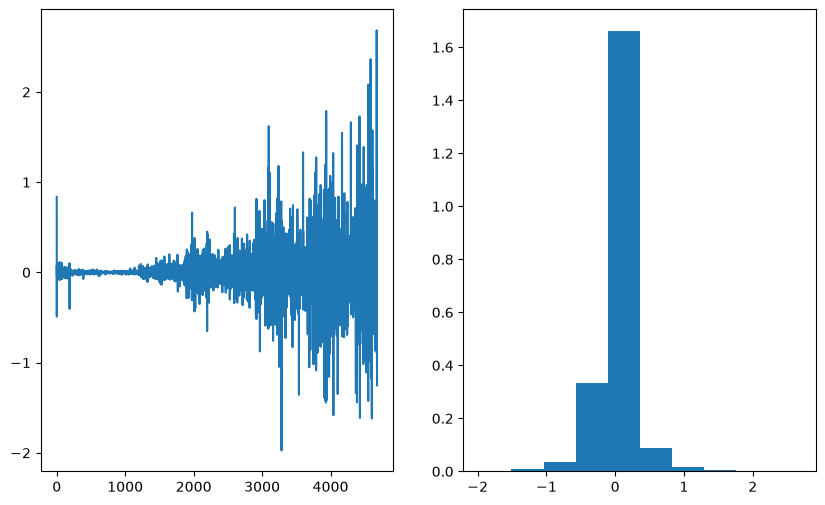

In [201]:
residual = arima_model.resid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.plot(residual)
ax2.hist(residual, density=True);

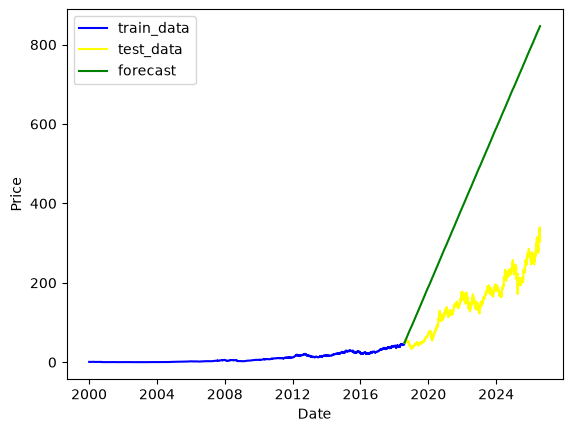

In [208]:
plt.plot(train.index, train.values, label="train_data", color="blue")
plt.plot(test.index, test.values, label="test_data", color="yellow")
plt.plot(test.index, forecast, label="forecast", color="green")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price");

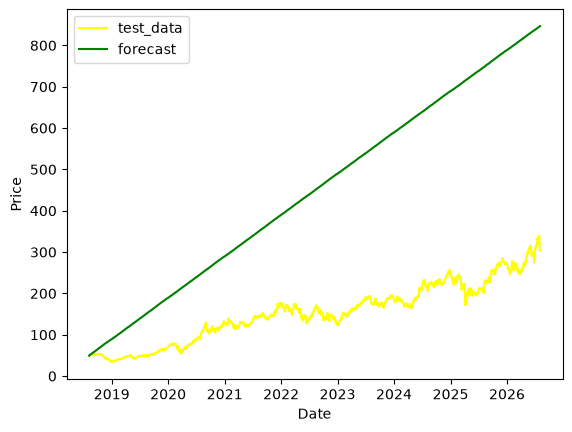

In [212]:
plt.plot(test.index, test.values, label="test_data", color="yellow")
plt.plot(test.index, forecast, label="forecast", color="green")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price");

In [222]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error 

In [218]:
mean_absolute_error(test.values, forecast)

295.25778208935577

In [219]:
root_mean_squared_error(test, forecast)

336.9323377004525

In [226]:
mean_absolute_percentage_error(test, forecast) * 100


184.74891468031683